In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import librosa
from sklearn import preprocessing
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score,f1_score, precision_score, roc_auc_score, recall_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.utils.fixes import loguniform
from sklearn.decomposition import PCA, KernelPCA, FastICA
from scipy.signal import medfilt
import scipy.io as sio

In [3]:
# load features and labels in the dataset

# Load the .mat file
roi_mask = sio.loadmat(os.path.realpath('/content/drive/MyDrive/ff/Extrated_spec_feature.mat'))
roi_unwrap = sio.loadmat(os.path.realpath('/content/drive/MyDrive/ff/Extracted_masked_unwrap.mat'))
roi_phase = sio.loadmat(os.path.realpath('/content/drive/MyDrive/ff/Extracted_masked_phase.mat'))
radar_s = sio.loadmat(os.path.realpath('/content/drive/MyDrive/ff/Radar_feature_spec.mat'))
radar_m_s = sio.loadmat(os.path.realpath('/content/drive/MyDrive/ff/Radar_feature_maskspec.mat'))


# Extract and convert arrays to NumPy arrays
roi_mask = np.array(roi_mask['M'])
roi_unwrap = np.array(roi_unwrap['stored_unwrap'])
roi_phase = np.array(roi_phase['stored_phase'])
radar_s = np.array(radar_s['feature_matrix_spec'])
radar_m_s= np.array(radar_m_s['radar_feature_matrix_maskspec'])

print(roi_mask.shape)

# Load the feature and label
mask_roi_feature = roi_mask[:,0:-1]
label = roi_mask[:,-1]
print(roi_mask.shape)
print(label.shape)

print('roi_unwrap',roi_unwrap.shape)
print('roi_phase',roi_phase.shape)
print('radar_s',radar_s.shape)
print('radar_m_s',radar_m_s.shape)


(1629, 69)
(1629, 69)
(1629,)
roi_unwrap (1629, 69)
roi_phase (1629, 69)
radar_s (1629, 21)
radar_m_s (1629, 21)


In [4]:
#delete the labels
roi_mask=np.delete(roi_mask,68,axis=1)
roi_unwrap=np.delete(roi_unwrap,68,axis=1)
roi_phase=np.delete(roi_phase,68,axis=1)

print(roi_mask.shape)
#fature combination
feature_all = np.hstack((roi_mask,roi_unwrap,roi_phase,radar_s,radar_m_s))


(1629, 68)


In [5]:
print(feature_all.shape)

(1629, 246)


In [6]:
# train_test split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(feature_all, label, test_size=0.2, random_state=42)
print(X_train.shape)
print(X_test.shape)

(1303, 246)
(326, 246)


In [8]:
# perform feature selection with SFS
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.neighbors import KNeighborsClassifier
from sklearn.datasets import load_iris
#svmm = SVC(kernel='rbf', C=10, gamma='scale',coef0=0.0, tol=1e-3)
svmm = SVC(kernel = 'poly', degree=2)
sfs = SequentialFeatureSelector(svmm, n_features_to_select=28)
sfs.fit(X_train, y_train)
# selected_features = X_train.columns[sfs.get_support()]
print(sfs.get_support())

[False False  True False False False False False False False  True False
  True False  True False  True  True  True  True  True  True  True  True
  True False  True False  True False  True False  True  True False False
 False False False False False False False  True False False False False
 False False False False False False False False False False False False
 False False False False False False False False False False False  True
 False False False False False False False False False False False False
 False False False False False False False False False False False False
 False False False False False False False False False False False False
 False False False False False False False False False False False False
 False False False False False False False False False  True False  True
 False False False False False False False False False False False False
 False False False False False False False False False False False False
 False False False False False False False False Fa

In [9]:
X_train_sfs = X_train[:,np.array(sfs.get_support())]
print(X_train_sfs.shape)

(1303, 28)


In [10]:
from sklearn.manifold import TSNE
tsne = TSNE(
        n_components=2,
        init="random",
        random_state=0,
        perplexity=30,
    )
Y = tsne.fit_transform(X_train_sfs)


(-43.79299392700195, 37.28698959350586, -72.43144607543945, 74.55818557739258)

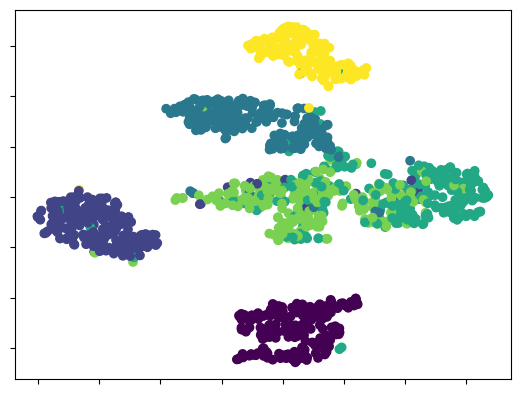

In [11]:
import matplotlib.pyplot as plt
from matplotlib.ticker import NullFormatter
fig, ax = plt.subplots()
color = np.random.uniform(15, 80, len(X_train_sfs))
ax.scatter(Y[:, 0], Y[:, 1],c=y_train)
ax.xaxis.set_major_formatter(NullFormatter())
ax.yaxis.set_major_formatter(NullFormatter())
ax.axis("tight")

In [ ]:
#feature selection basked on tree
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.feature_selection import SelectFromModel

clf = ExtraTreesClassifier(n_estimators=50)
clf = clf.fit(X_train, y_train)
selector = SelectFromModel(clf,threshold=0.006).fit(X_train,y_train)
feature_selected = selector.transform(X_train)
print(feature_selected.shape)

(1303, 37)


In [12]:
## model selection: 10-fold cross validation with grid search
# SVM
svm_param_grid = {'kernel': ['linear', 'rbf','poly'], 'C': [0.1, 1, 10]}
svm = SVC(gamma='scale',coef0=0.0, tol=1e-3)
grid_search_2 = GridSearchCV(svm, svm_param_grid, scoring='accuracy', cv=10)
grid_search_2.fit(X_train_sfs,y_train)
# Get the best hyperparameters and model
best_params_2 = grid_search_2.best_params_
best_model_2 = grid_search_2.best_estimator_
best_score_2 = grid_search_2.best_score_
print("Best accuracy on validation set: " + str(best_score_2))
print("Best model hyperparameters: " + str(best_params_2))
print("training time of best model: " + str(grid_search_2.cv_results_['mean_fit_time'][np.argmax(grid_search_2.cv_results_['mean_test_score'])]))
import joblib
joblib.dump(best_model_2, "/content/drive/MyDrive/ff/best_model_sfs.pkl")

Best accuracy on validation set: 0.9155901350557839
Best model hyperparameters: {'C': 10, 'kernel': 'rbf'}
training time of best model: 0.03760559558868408


['/content/drive/MyDrive/ff/best_model_sfs.pkl']

In [ ]:
#决策树选出来的svm训练
## model selection: 10-fold cross validation with grid search
# SVM
svm_param_grid = {'kernel': ['linear', 'rbf','poly'], 'C': [0.1, 1, 10]}
svm = SVC(gamma='scale',coef0=0.0, tol=1e-3)
grid_search_2 = GridSearchCV(svm, svm_param_grid, scoring='accuracy', cv=10)
grid_search_2.fit(feature_selected,y_train)
# Get the best hyperparameters and model
best_params_2 = grid_search_2.best_params_
best_model_2 = grid_search_2.best_estimator_
best_score_2 = grid_search_2.best_score_
print("Best accuracy on validation set: " + str(best_score_2))
print("Best model hyperparameters: " + str(best_params_2))
print("training time of best model: " + str(grid_search_2.cv_results_['mean_fit_time'][np.argmax(grid_search_2.cv_results_['mean_test_score'])]))


Best accuracy on validation set: 0.9186553141514974
Best model hyperparameters: {'C': 10, 'kernel': 'rbf'}
training time of best model: 0.02470083236694336


In [ ]:
# Save models
import joblib
joblib.dump(best_model_2, "/content/drive/MyDrive/ff/best_model_tree.pkl")


['/content/drive/MyDrive/ff/best_model_tree.pkl']

In [13]:
def Classifier(clf,x_train,y_train,x_test,y_test):

    #fit the model
    clf.fit(x_train,y_train)

    #predict on the test set
    y_pred = clf.predict(x_test)

    # print the scores
    print("Accuracy: " + str(accuracy_score(y_test,y_pred)))
    print("Precison score: " + str(precision_score(y_test,y_pred, average='macro')))
    print("Recall score: " + str(recall_score(y_test,y_pred, average='macro')))
    print("F1 score: " + str(f1_score(y_test,y_pred, average='macro')))

    # plot the confusion matrix

    plt.figure(figsize=(5,5))
    cm = confusion_matrix(y_test,y_pred,labels=clf.classes_)
    #plt.imshow(cm)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=clf.classes_)
    disp.plot()
    plt.title("Confusion Matrix")
    plt.show()

(326, 28)
Accuracy: 0.901840490797546
Precison score: 0.89815159794668
Recall score: 0.8880909180490114
F1 score: 0.8903200270423638


<Figure size 500x500 with 0 Axes>

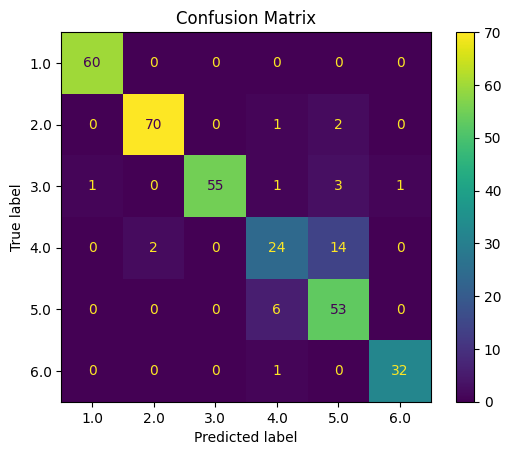

In [14]:
## test the performance
# feature standardization on test
X_test = scaler.transform(X_test)
X_test_sfs = X_test[:,np.array(sfs.get_support())]
print(X_test_sfs.shape)
# perform training with the best model, and perform testing on test set
Classifier(best_model_2,X_train_sfs,y_train,X_test_sfs,y_test)

(326, 37)
Accuracy: 0.8957055214723927
Precison score: 0.8940780972013526
Recall score: 0.886110107169277
F1 score: 0.8889026009493514


<Figure size 500x500 with 0 Axes>

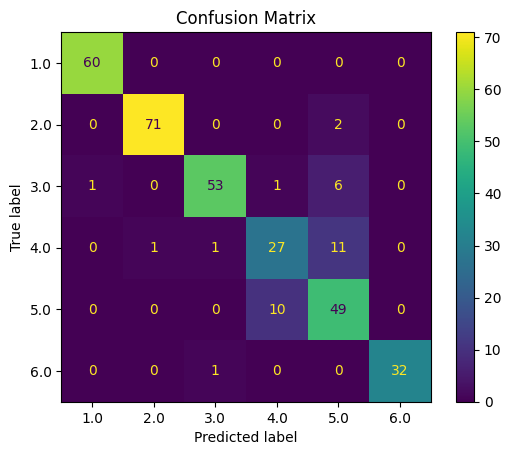

In [ ]:
## test the performance with the selector based on tree
# feature standardization on test
X_test = scaler.transform(X_test)
X_test_tree=selector.transform(X_test)
print(X_test_tree.shape)
# perform training with the best model, and perform testing on test set
Classifier(best_model_2,feature_selected,y_train,X_test_tree,y_test)

KNN

In [15]:
## model selection: 10-fold cross validation with grid search

# KNN
knn_param_grid = {'n_neighbors': [3, 5, 7, 9, 11, 13, 15]}
knn = KNeighborsClassifier()
grid_search_1 = GridSearchCV(knn, knn_param_grid, scoring='accuracy', cv=10)
grid_search_1.fit(X_train_sfs,y_train)
# Get the best hyperparameters and model
best_params_1 = grid_search_1.best_params_
best_model_1 = grid_search_1.best_estimator_
best_score_1 = grid_search_1.best_score_
print("Best accuracy on validation set: " + str(best_score_1))
print("Best model hyperparameters: " + str(best_params_1))
print("training time of best model: " + str(grid_search_1.cv_results_['mean_fit_time'][np.argmax(grid_search_1.cv_results_['mean_test_score'])]))


joblib.dump(best_model_1, "/content/drive/MyDrive/ff/best_model_knn.pkl")

Best accuracy on validation set: 0.9025601879036994
Best model hyperparameters: {'n_neighbors': 7}
training time of best model: 0.004655790328979492


['/content/drive/MyDrive/ff/best_model_knn.pkl']

Accuracy: 0.9049079754601227
Precison score: 0.8973596465705506
Recall score: 0.8971756809397688
F1 score: 0.8964569063046596


<Figure size 500x500 with 0 Axes>

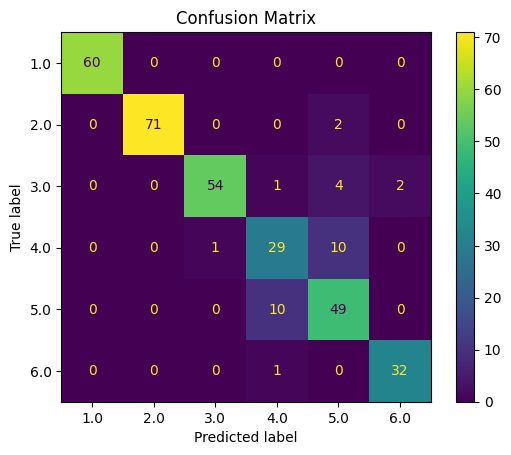

In [16]:
# perform training with the best model, and perform testing on test set
Classifier(best_model_1,X_train_sfs,y_train,X_test_sfs,y_test)

Random forest

In [17]:
rf_param_grid = {'n_estimators': range(10,101,10), 'max_features': [3,5,7,9]}
rf = RandomForestClassifier(criterion="gini")
grid_search_4 = GridSearchCV(rf, rf_param_grid, scoring='accuracy', cv=10)
grid_search_4.fit(X_train_sfs,y_train)
# Get the best hyperparameters and model
best_params_4 = grid_search_4.best_params_
best_model_4 = grid_search_4.best_estimator_
best_score_4 = grid_search_4.best_score_
print("Best accuracy on validation set: " + str(best_score_4))
print("Best model hyperparameters: " + str(best_params_4))
print("training time of best model: " + str(grid_search_4.cv_results_['mean_fit_time'][np.argmax(grid_search_4.cv_results_['mean_test_score'])]))

joblib.dump(best_model_4, "/content/drive/MyDrive/ff/best_model_RF.pkl")

Best accuracy on validation set: 0.9109806224310042
Best model hyperparameters: {'max_features': 7, 'n_estimators': 100}
training time of best model: 0.3450008869171143


['/content/drive/MyDrive/ff/best_model_RF.pkl']

Accuracy: 0.911042944785276
Precison score: 0.9050355468925845
Recall score: 0.9067582038628029
F1 score: 0.9049957451164415


<Figure size 500x500 with 0 Axes>

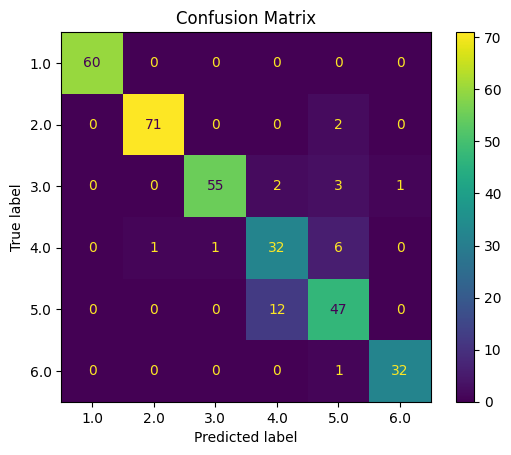

In [18]:
# perform training with the best model, and perform testing on test set
Classifier(best_model_4,X_train_sfs,y_train,X_test_sfs,y_test)